# Задание 1. Исследование набора данных

## 1. <a href="#toc" title="К содержанию" id="dataset" style="text-decoration: none; color:#81BCD9;">Набор данных:</a> <a href="https://www.kaggle.com/mczielinski/bitcoin-historical-data" title="Bitcoin Historical Data" style="text-decoration: none; color:#FF8D6F; font-size:15px; font-weight:bold;" rel="noopener noreferrer" target="_blank">Bitcoin Historical Data</a>
***

## <a id="toc" style="text-decoration: none; color:#81BCD9;">Содержание:</a>
<ol style="font-size: 22px;">
    <li><a href="#dataset" style="text-decoration: none; color:#55C385;">Набор данных</a></li>
    <li><a href="#dataset-description" style="text-decoration: none; color:#55C385;">Описание набора данных</a></li>
    <li><a href="#attributes-analysis" style="text-decoration: none; color:#55C385;">Анализ атрибутов</a></li>
    <li><a href="#attributes-correlation" style="text-decoration: none; color:#55C385;">Анализ корреляции атрибутов</a></li>
</ol>

## 2. <a href="#toc" title="К содержанию" id="dataset-description" style="text-decoration: none; color:#81BCD9;">Описание набора данных</a>
***

### Общая информация
- Предметная область: криптовалюта
- Источник данных: <a href="https://bitcoincharts.com/" title="Bitcoincharts" style="text-decoration: none; color:#FF8D6F; font-weight: bold;" rel="noopener noreferrer" target="_blank">Bitcoincharts</a>
- Характер данных: реальные

### Атрибуты
1. **Timestamp**:`int` — время начала временного окна (каждое окно по $60c$) в формате Unix
2. **Open**:`float` — цена на момент открытия временного окна
3. **High**:`float` — $max_{цена}$ во временном окне
4. **Low**:`float` — $min_{цена}$ во временном окне
5. **Close**:`float` — цена на момент закрытия временного окна
6. **Volume_(BTC)**:`float` — объём транзакции в $BTC$
7. **Volume_(Currency)**:`float` — объём транзакции в валюте
8. **Weighted_Price**:`float` — курс $BTC$ для данной валюты

### Описание задачи анализа отсутствует

## 3. <a href="#toc" title="К содержанию" id="attributes-analysis" style="text-decoration: none; color:#81BCD9">Анализ атрибутов</a>
***

- Среднее значение атрибута <font size="6px">$\overline{x}$</font> буду считать по формуле: <font size="6px">$\overline{x}=\frac{\sum\limits_{i=1}^{N}x_i}{N}$</font>
    - `mean_attribute = df['attribute'].mean()`, где `attribute` — название атрибута
- Среднеквадратическое отклонение <font size="6px">$s_x$</font> буду считать по формуле: <font size="6px">$s_x=\sqrt{\frac{\sum\limits_{i=1}^{N}(x_i-\overline{x})^2}{N-1}}$</font>
    - `sd_attribute = df['attribute'].std(ddof=1)`, где `attribute` — название атрибута
- Коэффициент вариации (он тоже будет полезен) буду считать по формуле: <font size="6px">$c_V=\frac{s_x}{\overline{x}}$</font>
    - `c_v_attribute = sd_attribute / mean_attribute`, где `attribute` — название атрибута
- Для прорисовки гистрограмм буду использовать команду `plt.hist(df['attribute']);`, где `attribute` — название атрибута, также для диаграмм буду вводить дополнительные переменные и рисунки/надписи для чуть лучшей чем совсем плохая визуализации
- Выбросы буду определять с помощью верхней границы межквартильного диапазона по формуле: <font size="6px">$b_u=2.5Q_3-1.5Q_1$</font>
    - `outliers_amount_attribute = len(df[df['attribute'] > upper_bound])`, где `attribute` — название атрибута
- Количество пропущенных значений буду вычислять подсчётом количества ячеек, где в качестве значения указано `NaN`
    - `df['attribute'].isna().sum()`, где `attribute` — название атрибута
- Вариантов обработки значений у меня два (зависит от типа анализа): отбросить или оставить

Подключу `pandas`, `seaborn`, `matplotlib.pyplot` и `matplotlib.patches`, после чего установлю стили для графиков и считаю файл с набором данных `bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv`.<br>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sns.set(rc={'figure.figsize':(15,15)})
sns.set_style('whitegrid')

thicc = 4
half_thicc = thicc >> 1

df = pd.read_csv('bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv')

### &emsp;1. Timestamp

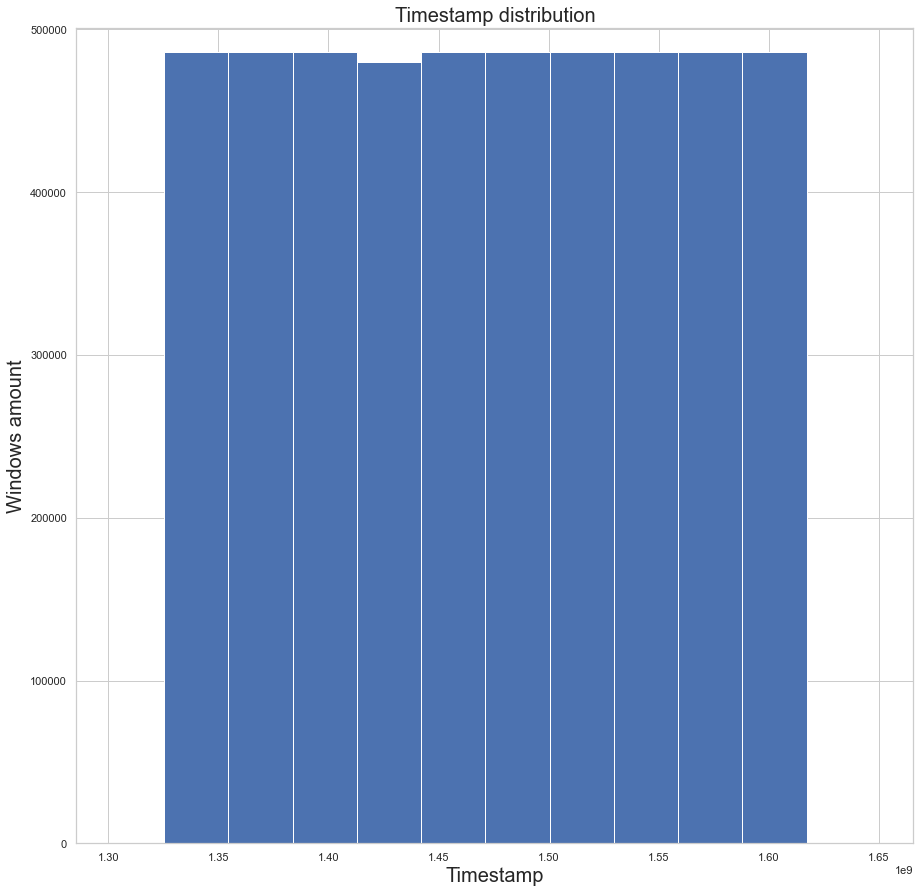

In [2]:
mean_timestamp = df['Timestamp'].mean()
sd_timestamp = df['Timestamp'].std(ddof=1)
Q3_timestamp = df['Timestamp'].quantile(0.75)
b_u_timestamp = Q3_timestamp + 1.5 * (Q3_timestamp - df['Timestamp'].quantile(0.25))
min_timestamp = df['Timestamp'].min()
left_border_timestamp = min_timestamp * 0.97
max_timestamp = df['Timestamp'].max()
right_border_timestamp = max_timestamp * 1.03
interval_timestamp = (df['Timestamp'].max() - df['Timestamp'].min()) / 10
maximum_timestamp = len(df[df['Timestamp'] <= min_timestamp + interval_timestamp])
for i in range (1,10):
    possible_max = len(df[(df['Open'] > min_timestamp + i * interval_timestamp)
                        & (df['Open'] <= min_timestamp + (i + 1) * interval_timestamp)])
    if maximum_timestamp < possible_max:
        maximum_timestamp = possible_max
ceil_timestamp = maximum_timestamp * 1.03
amount_timestamp = len(df['Timestamp'])
amount_na_timestamp = df['Timestamp'].isna().sum()
amount_filled_timestamp = len(df['Timestamp']) - amount_na_timestamp
outliers_amount_timestamp = len(df[df['Timestamp'] > b_u_timestamp])
outliers_percent_timestamp = outliers_amount_timestamp * 100 / amount_filled_timestamp
non_outliers_amount_timestamp = len(df[df['Timestamp'] <= b_u_timestamp])
c_v_timestamp = sd_timestamp / mean_timestamp

plt.axis([left_border_timestamp, right_border_timestamp, 0, ceil_timestamp])
plt.xlabel('Timestamp', fontsize=20)
plt.ylabel('Windows amount', fontsize=20)
plt.title('Timestamp distribution', fontsize=20)
plt.grid(True)
plt.hist(df['Timestamp']);

In [3]:
print(f'Среднее значение Timestamp:\t\t\t\t\t\t\t\t{mean_timestamp}\n'
f'Среднеквадратическое отклонение Timestamp:\t\t\t\t\t\t{sd_timestamp}\n'
f'Коэффициент вариации Timestamp:\t\t\t\t\t\t\t\t{c_v_timestamp}\n'
f'Верхняя граница межквартильного диапазона Timestamp:\t\t\t\t\t{b_u_timestamp}\n'
f'Количество значений Timestamp всего:\t\t\t\t\t\t\t{amount_timestamp}\n'
f'Количество пропущенных значений Timestamp:\t\t\t\t\t\t{amount_na_timestamp}\n'
f'Количество значений Timestamp без пропущенных:\t\t\t\t\t\t{amount_filled_timestamp}\n'
f'Количество выбросов Timestamp:\t\t\t\t\t\t\t\t{outliers_amount_timestamp}\n'
f'Процент выбросов (от общего значения Timestamp без пропущенных):\t\t\t{outliers_percent_timestamp}\n'
f'Количество значений Timestamp без выбросов:\t\t\t\t\t\t{non_outliers_amount_timestamp}\n\n'
'Очень бесполезный анализ (конкретно для этого атрибута, когда он отделён от всех остальных).\n'
'Да, есть небольшая просадка значений в 4 интервале, но она ни на что не влияет и связана с техническими\n'
'неполадками в работе API биржи, как заявляет автор.')

Среднее значение Timestamp:								1471300766.5042922
Среднеквадратическое отклонение Timestamp:						84280194.37553182
Коэффициент вариации Timestamp:								0.05728277745397746
Верхняя граница межквартильного диапазона Timestamp:					1763452560.0
Количество значений Timestamp всего:							4857377
Количество пропущенных значений Timestamp:						0
Количество значений Timestamp без пропущенных:						4857377
Количество выбросов Timestamp:								0
Процент выбросов (от общего значения Timestamp без пропущенных):			0.0
Количество значений Timestamp без выбросов:						4857377

Очень бесполезный анализ (конкретно для этого атрибута, когда он отделён от всех остальных).
Да, есть небольшая просадка значений в 4 интервале, но она ни на что не влияет и связана с техническими
неполадками в работе API биржи, как заявляет автор.


### &emsp;2. Open

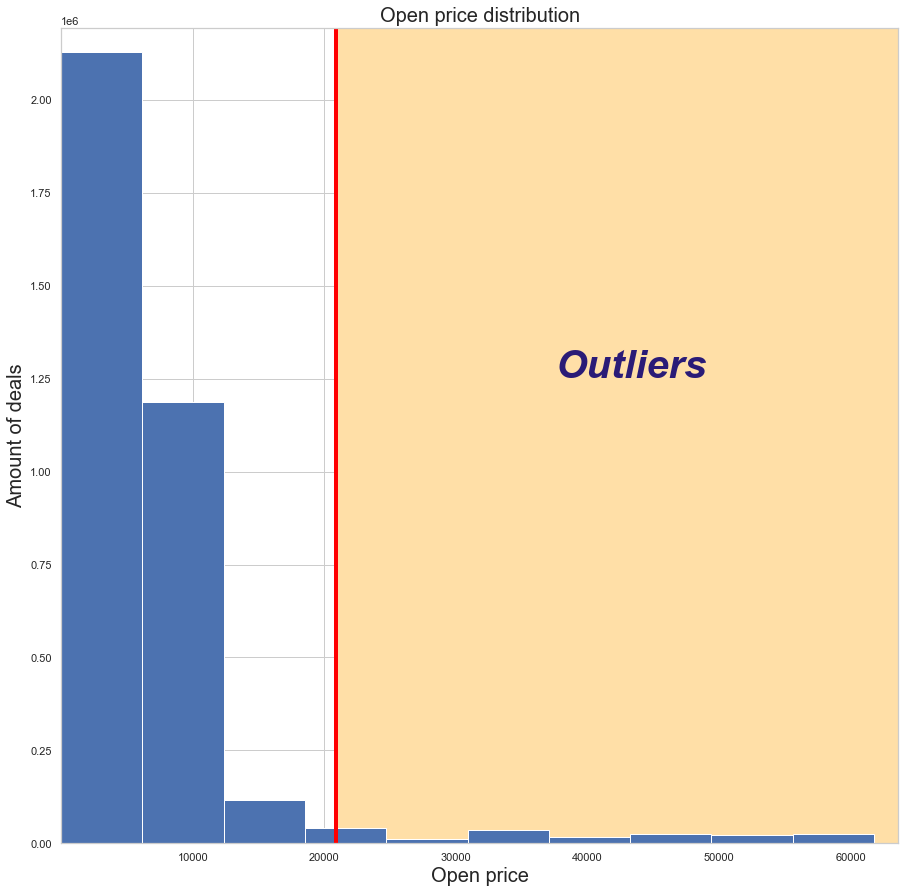

In [4]:
mean_open = df['Open'].mean()
sd_open = df['Open'].std(ddof=1)
Q3_open = df['Open'].quantile(0.75)
b_u_open = Q3_open + 1.5 * (Q3_open - df['Open'].quantile(0.25))
min_open = df['Open'].min()
left_border_open = min_open * 0.97
max_open = df['Open'].max()
right_border_open = max_open * 1.03
interval_open = (df['Open'].max() - df['Open'].min()) / 10
maximum_open = len(df[df['Open'] <= min_open + interval_open])
for i in range (1,10):
    possible_max = len(df[(df['Open'] > min_open + i * interval_open)
                        & (df['Open'] <= min_open + (i + 1) * interval_open)])
    if maximum_open < possible_max:
        maximum_open = possible_max
ceil_open = maximum_open * 1.03
amount_open = len(df['Open'])
amount_na_open = df['Open'].isna().sum()
amount_filled_open = len(df['Open']) - amount_na_open
outliers_amount_open = len(df[df['Open'] > b_u_open])
outliers_percent_open = outliers_amount_open * 100 / amount_filled_open
non_outliers_amount_open = len(df[df['Open'] <= b_u_open])
c_v_open = sd_open / mean_open

plt.axis([left_border_open, right_border_open, 0, ceil_open])
plt.xlabel('Open price', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Open price distribution', fontsize=20)
plt.plot([b_u_open - half_thicc, b_u_open - half_thicc], [0, ceil_open], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_open, 0), right_border_open - b_u_open, ceil_open, color="#FFDFA7"))
plt.gca().text((right_border_open + b_u_open) / 2.25, ceil_open / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Open']);

In [5]:
print(f'Среднее значение Open:\t\t\t\t\t\t\t\t\t{mean_open}\n'
f'Среднеквадратическое отклонение Open:\t\t\t\t\t\t\t{sd_open}\n'
f'Коэффициент вариации Open:\t\t\t\t\t\t\t\t{c_v_open}\n'
f'Верхняя граница межквартильного диапазона Open:\t\t\t\t\t\t{b_u_open}\n'
f'Количество значений Open всего:\t\t\t\t\t\t\t\t{amount_open}\n'
f'Количество пропущенных значений Open:\t\t\t\t\t\t\t{amount_na_open}\n'
f'Количество значений Open без пропущенных:\t\t\t\t\t\t{amount_filled_open}\n'
f'Количество выбросов Open:\t\t\t\t\t\t\t\t{outliers_amount_open}\n'
f'Процент выбросов (от общего значения Open без пропущенных):\t\t\t\t{outliers_percent_open}\n'
f'Количество значений Open без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_open}\n\n'
'Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов')

Среднее значение Open:									6009.023680137011
Среднеквадратическое отклонение Open:							8996.24735115404
Коэффициент вариации Open:								1.4971229653980855
Верхняя граница межквартильного диапазона Open:						20902.385000000002
Количество значений Open всего:								4857377
Количество пропущенных значений Open:							1243608
Количество значений Open без пропущенных:						3613769
Количество выбросов Open:								149757
Процент выбросов (от общего значения Open без пропущенных):				4.144066762430028
Количество значений Open без выбросов:							3464012

Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов


### &emsp;3. High

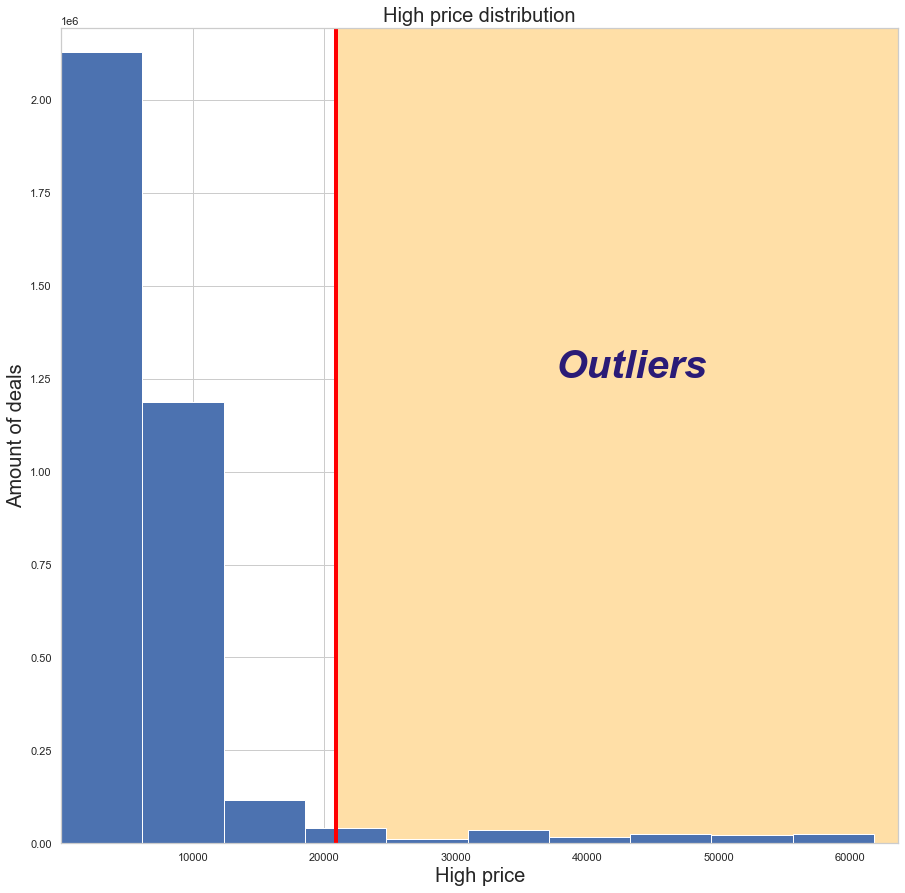

In [6]:
mean_high = df['High'].mean()
sd_high = df['High'].std(ddof=1)
Q3_high = df['High'].quantile(0.75)
b_u_high = Q3_high + 1.5 * (Q3_high - df['High'].quantile(0.25))
min_high = df['High'].min()
left_border_high = min_high * 0.97
max_high = df['High'].max()
right_border_high = max_high * 1.03
interval_high = (df['High'].max() - df['High'].min()) / 10
maximum_high = len(df[df['High'] <= min_high + interval_high])
for i in range (1,10):
    possible_max = len(df[(df['High'] > min_high + i * interval_high)
                        & (df['High'] <= min_high + (i + 1) * interval_high)])
    if maximum_high < possible_max:
        maximum_high = possible_max
ceil_high = maximum_high * 1.03
amount_high = len(df['High'])
amount_na_high = df['High'].isna().sum()
amount_filled_high = len(df['High']) - amount_na_high
outliers_amount_high = len(df[df['High'] > b_u_high])
outliers_percent_high = outliers_amount_high * 100 / amount_filled_high
non_outliers_amount_high = len(df[df['High'] <= b_u_high])
c_v_high = sd_high / mean_high

plt.axis([left_border_high, right_border_high, 0, ceil_high])
plt.xlabel('High price', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('High price distribution', fontsize=20)
plt.plot([b_u_high - half_thicc, b_u_high - half_thicc], [0, ceil_high], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_high, 0), right_border_high - b_u_high, ceil_high, color="#FFDFA7"))
plt.gca().text((right_border_high + b_u_high) / 2.25, ceil_high / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['High']);

In [7]:
print(f'Среднее значение High:\t\t\t\t\t\t\t\t\t{mean_high}\n'
f'Среднеквадратическое отклонение High:\t\t\t\t\t\t\t{sd_high}\n'
f'Коэффициент вариации High:\t\t\t\t\t\t\t\t{c_v_high}\n'
f'Верхняя граница межквартильного диапазона High:\t\t\t\t\t\t{b_u_high}\n'
f'Количество значений High всего:\t\t\t\t\t\t\t\t{amount_high}\n'
f'Количество пропущенных значений High:\t\t\t\t\t\t\t{amount_na_high}\n'
f'Количество значений High без пропущенных:\t\t\t\t\t\t{amount_filled_high}\n'
f'Количество выбросов High:\t\t\t\t\t\t\t\t{outliers_amount_high}\n'
f'Процент выбросов (от общего значения High без пропущенных):\t\t\t\t{outliers_percent_high}\n'
f'Количество значений High без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_high}\n\n'
'Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов')

Среднее значение High:									6013.357081609536
Среднеквадратическое отклонение High:							9003.521006376617
Коэффициент вариации High:								1.4972536778020062
Верхняя граница межквартильного диапазона High:						20916.449999999997
Количество значений High всего:								4857377
Количество пропущенных значений High:							1243608
Количество значений High без пропущенных:						3613769
Количество выбросов High:								149758
Процент выбросов (от общего значения High без пропущенных):				4.144094434370321
Количество значений High без выбросов:							3464011

Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов


### &emsp;4. Low

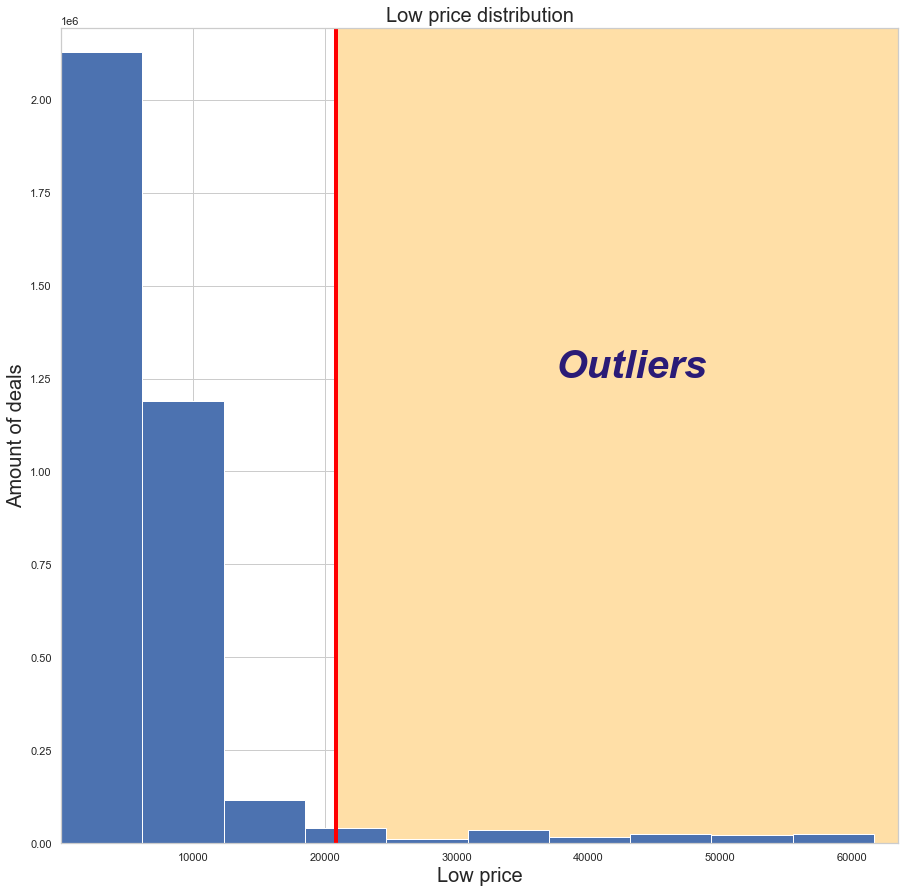

In [8]:
mean_low = df['Low'].mean()
sd_low = df['Low'].std(ddof=1)
Q3_low = df['Low'].quantile(0.75)
b_u_low = Q3_low + 1.5 * (Q3_low - df['Low'].quantile(0.25))
min_low = df['Low'].min()
left_border_low = min_low * 0.97
max_low = df['Low'].max()
right_border_low = max_low * 1.03
interval_low = (df['Low'].max() - df['Low'].min()) / 10
maximum_low = len(df[df['Low'] <= min_low + interval_low])
for i in range (1,10):
    possible_max = len(df[(df['Low'] > min_low + i * interval_low)
                        & (df['Low'] <= min_low + (i + 1) * interval_low)])
    if maximum_low < possible_max:
        maximum_low = possible_max
ceil_low = maximum_low * 1.03
amount_low = len(df['Low'])
amount_na_low = df['Low'].isna().sum()
amount_filled_low = len(df['Low']) - amount_na_low
outliers_amount_low = len(df[df['Low'] > b_u_low])
outliers_percent_low = outliers_amount_low * 100 / amount_filled_low
non_outliers_amount_low = len(df[df['Low'] <= b_u_low])
c_v_low = sd_low / mean_low

plt.axis([left_border_low, right_border_low, 0, ceil_low])
plt.xlabel('Low price', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Low price distribution', fontsize=20)
plt.plot([b_u_low - half_thicc, b_u_low - half_thicc], [0, ceil_low], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_low, 0), right_border_low - b_u_low, ceil_low, color="#FFDFA7"))
plt.gca().text((right_border_low + b_u_low) / 2.25, ceil_low / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Low']);

In [9]:
print(f'Среднее значение Low:\t\t\t\t\t\t\t\t\t{mean_low}\n'
f'Среднеквадратическое отклонение Low:\t\t\t\t\t\t\t{sd_low}\n'
f'Коэффициент вариации Low:\t\t\t\t\t\t\t\t{c_v_low}\n'
f'Верхняя граница межквартильного диапазона Low:\t\t\t\t\t\t{b_u_low}\n'
f'Количество значений Low всего:\t\t\t\t\t\t\t\t{amount_low}\n'
f'Количество пропущенных значений Low:\t\t\t\t\t\t\t{amount_na_low}\n'
f'Количество значений Low без пропущенных:\t\t\t\t\t\t{amount_filled_low}\n'
f'Количество выбросов Low:\t\t\t\t\t\t\t\t{outliers_amount_low}\n'
f'Процент выбросов (от общего значения Low без пропущенных):\t\t\t\t{outliers_percent_low}\n'
f'Количество значений Low без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_low}\n\n'
'Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов')

Среднее значение Low:									6004.4880035062515
Среднеквадратическое отклонение Low:							8988.778318952896
Коэффициент вариации Low:								1.4970099555039502
Верхняя граница межквартильного диапазона Low:						20887.445
Количество значений Low всего:								4857377
Количество пропущенных значений Low:							1243608
Количество значений Low без пропущенных:						3613769
Количество выбросов Low:								149757
Процент выбросов (от общего значения Low без пропущенных):				4.144066762430028
Количество значений Low без выбросов:							3464012

Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов


### &emsp;5. Close

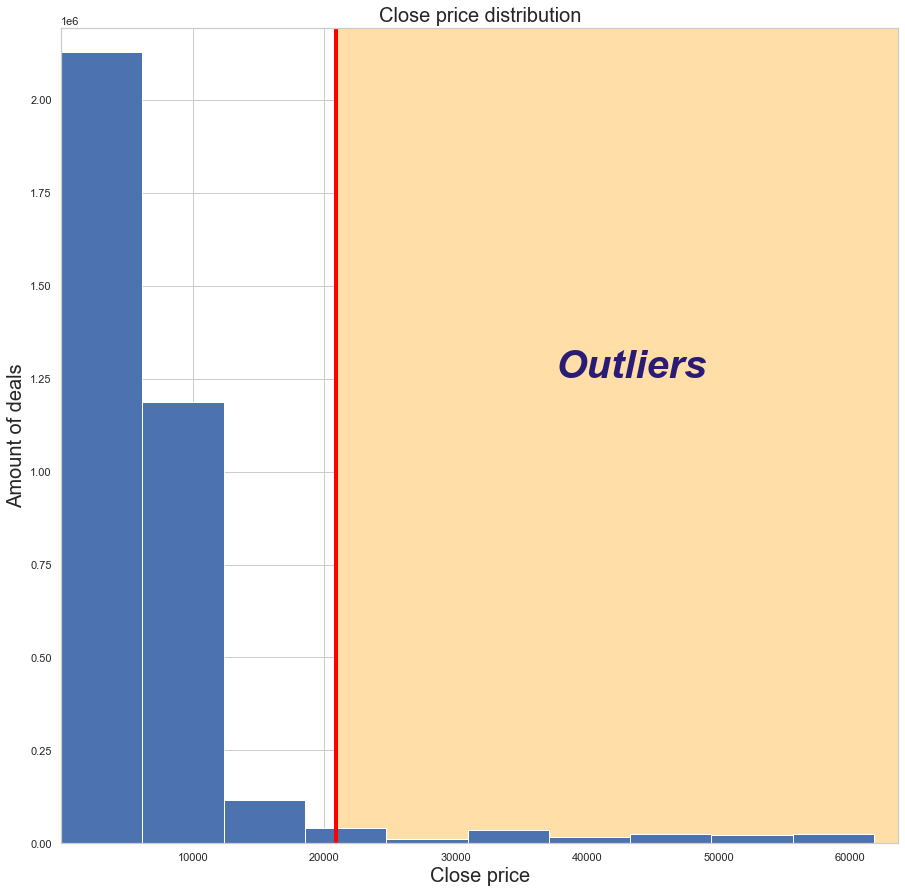

In [10]:
mean_close = df['Close'].mean()
sd_close = df['Close'].std(ddof=1)
Q3_close = df['Close'].quantile(0.75)
b_u_close = Q3_close + 1.5 * (Q3_close - df['Close'].quantile(0.25))
min_close = df['Close'].min()
left_border_close = min_close * 0.97
max_close = df['Close'].max()
right_border_close = max_close * 1.03
interval_close = (df['Close'].max() - df['Close'].min()) / 10
maximum_close = len(df[df['Close'] <= min_close + interval_close])
for i in range (1,10):
    possible_max = len(df[(df['Close'] > min_close + i * interval_close)
                        & (df['Close'] <= min_close + (i + 1) * interval_close)])
    if maximum_close < possible_max:
        maximum_close = possible_max
ceil_close = maximum_close * 1.03
amount_close = len(df['Close'])
amount_na_close = df['Close'].isna().sum()
amount_filled_close = len(df['Close']) - amount_na_close
outliers_amount_close = len(df[df['Close'] > b_u_close])
outliers_percent_close = outliers_amount_close * 100 / amount_filled_close
non_outliers_amount_close = len(df[df['Close'] <= b_u_close])
c_v_close = sd_close / mean_close

plt.axis([left_border_close, right_border_close, 0, ceil_close])
plt.xlabel('Close price', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Close price distribution', fontsize=20)
plt.plot([b_u_close - half_thicc, b_u_close - half_thicc], [0, ceil_close], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_close, 0), right_border_close - b_u_close, ceil_close, color="#FFDFA7"))
plt.gca().text((right_border_close + b_u_close) / 2.25, ceil_close / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Close']);

In [11]:
print(f'Среднее значение Close:\t\t\t\t\t\t\t\t\t{mean_close}\n'
f'Среднеквадратическое отклонение Close:\t\t\t\t\t\t\t{sd_close}\n'
f'Коэффициент вариации Close:\t\t\t\t\t\t\t\t{c_v_close}\n'
f'Верхняя граница межквартильного диапазона Close:\t\t\t\t\t{b_u_close}\n'
f'Количество значений Close всего:\t\t\t\t\t\t\t{amount_close}\n'
f'Количество пропущенных значений Close:\t\t\t\t\t\t\t{amount_na_close}\n'
f'Количество значений Close без пропущенных:\t\t\t\t\t\t{amount_filled_close}\n'
f'Количество выбросов Close:\t\t\t\t\t\t\t\t{outliers_amount_close}\n'
f'Процент выбросов (от общего значения Close без пропущенных):\t\t\t\t{outliers_percent_close}\n'
f'Количество значений Close без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_close}\n\n'
'Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов')

Среднее значение Close:									6009.013545015653
Среднеквадратическое отклонение Close:							8996.359688354543
Коэффициент вариации Close:								1.4971441853075584
Верхняя граница межквартильного диапазона Close:					20902.11
Количество значений Close всего:							4857377
Количество пропущенных значений Close:							1243608
Количество значений Close без пропущенных:						3613769
Количество выбросов Close:								149758
Процент выбросов (от общего значения Close без пропущенных):				4.144094434370321
Количество значений Close без выбросов:							3464011

Коэффициент вариации говорит о том, что данные очень разрознены, имеется 4.1% выбросов


### &emsp;6. Volume_(BTC)

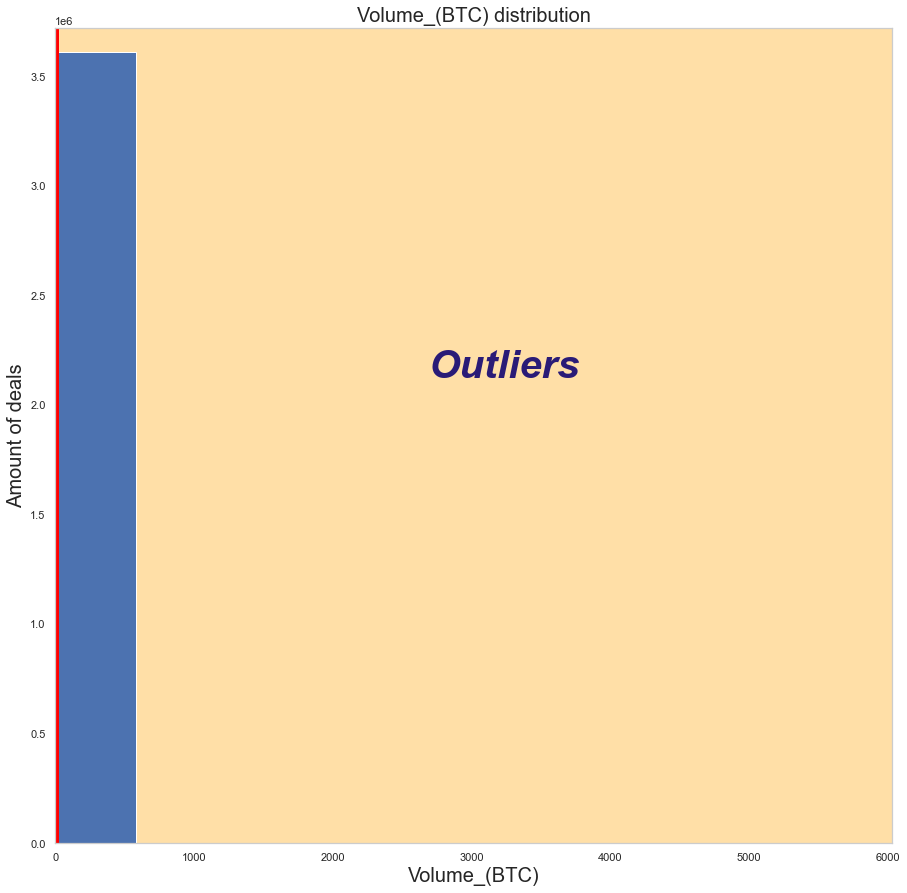

In [12]:
mean_volume_btc = df['Volume_(BTC)'].mean()
sd_volume_btc = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc = Q3_volume_btc + 1.5 * (Q3_volume_btc - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc = df['Volume_(BTC)'].min()
left_border_volume_btc = min_volume_btc * 0.97
max_volume_btc = df['Volume_(BTC)'].max()
right_border_volume_btc = max_volume_btc * 1.03
interval_volume_btc = (df['Volume_(BTC)'].max() - df['Volume_(BTC)'].min()) / 10
maximum_volume_btc = len(df[df['Volume_(BTC)'] <= min_volume_btc + interval_volume_btc])
for i in range (1,10):
    possible_max = len(df[(df['Volume_(BTC)'] > min_volume_btc + i * interval_volume_btc)
                        & (df['Volume_(BTC)'] <= min_volume_btc + (i + 1) * interval_volume_btc)])
    if maximum_volume_btc < possible_max:
        maximum_volume_btc = possible_max
ceil_volume_btc = maximum_volume_btc * 1.03
amount_volume_btc = len(df['Volume_(BTC)'])
amount_na_volume_btc = df['Volume_(BTC)'].isna().sum()
amount_filled_volume_btc = len(df['Volume_(BTC)']) - amount_na_volume_btc
outliers_amount_volume_btc = len(df[df['Volume_(BTC)'] > b_u_volume_btc])
outliers_percent_volume_btc = outliers_amount_volume_btc * 100 / amount_filled_volume_btc
non_outliers_amount_volume_btc = len(df[df['Volume_(BTC)'] <= b_u_volume_btc])
c_v_volume_btc = sd_volume_btc / mean_volume_btc

plt.axis([left_border_volume_btc, right_border_volume_btc, 0, ceil_volume_btc])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc - half_thicc, b_u_volume_btc - half_thicc], [0, ceil_volume_btc], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc, 0),
                                      right_border_volume_btc - b_u_volume_btc, ceil_volume_btc, color="#FFDFA7"))
plt.gca().text((right_border_volume_btc + b_u_volume_btc) / 2.25, ceil_volume_btc / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Volume_(BTC)']);

In [13]:
print(f'Среднее значение Volume_(BTC):\t\t\t\t\t\t\t\t\t{mean_volume_btc}\n'
f'Среднеквадратическое отклонение Volume_(BTC):\t\t\t\t\t\t\t{sd_volume_btc}\n'
f'Коэффициент вариации Volume_(BTC):\t\t\t\t\t\t\t\t{c_v_volume_btc}\n'
f'Верхняя граница межквартильного диапазона Volume_(BTC):\t\t\t\t\t\t{b_u_volume_btc}\n'
f'Количество значений Volume_(BTC) всего:\t\t\t\t\t\t\t\t{amount_volume_btc}\n'
f'Количество пропущенных значений Volume_(BTC):\t\t\t\t\t\t\t{amount_na_volume_btc}\n'
f'Количество значений Volume_(BTC) без пропущенных:\t\t\t\t\t\t{amount_filled_volume_btc}\n'
f'Количество выбросов Volume_(BTC):\t\t\t\t\t\t\t\t{outliers_amount_volume_btc}\n'
f'Процент выбросов (от общего значения Volume_(BTC) без пропущенных):\t\t\t\t{outliers_percent_volume_btc}\n'
f'Количество значений Volume_(BTC) без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_volume_btc}\n\n'
'Коэффициент вариации говорит о том, что данные очень сильно разрознены, имеется 11.9% выбросов\n'
'Гистограмму прорисую ещё несколько раз, т.к. предыдущая не очень-то наглядна')

Среднее значение Volume_(BTC):									9.323249222687261
Среднеквадратическое отклонение Volume_(BTC):							30.549891244121838
Коэффициент вариации Volume_(BTC):								3.2767429588583252
Верхняя граница межквартильного диапазона Volume_(BTC):						17.58087699
Количество значений Volume_(BTC) всего:								4857377
Количество пропущенных значений Volume_(BTC):							1243608
Количество значений Volume_(BTC) без пропущенных:						3613769
Количество выбросов Volume_(BTC):								429707
Процент выбросов (от общего значения Volume_(BTC) без пропущенных):				11.89082644740159
Количество значений Volume_(BTC) без выбросов:							3184062

Коэффициент вариации говорит о том, что данные очень сильно разрознены, имеется 11.9% выбросов
Гистограмму прорисую ещё несколько раз, т.к. предыдущая не очень-то наглядна


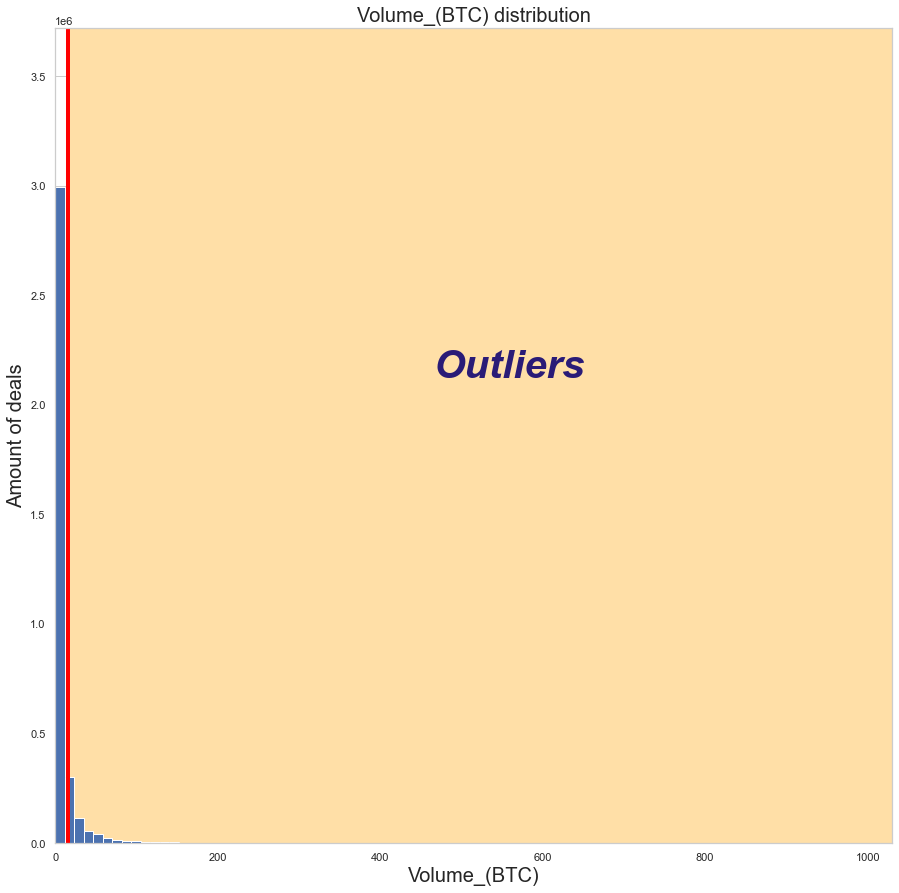

In [14]:
mean_volume_btc1 = df['Volume_(BTC)'].mean()
sd_volume_btc1 = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc1 = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc1 = Q3_volume_btc1 + 1.5 * (Q3_volume_btc1 - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc1 = df['Volume_(BTC)'].min()
left_border_volume_btc1 = min_volume_btc1 * 0.97
max_volume_btc1 = df['Volume_(BTC)'].max() - 4853.852166
right_border_volume_btc1 = max_volume_btc1 * 1.03
interval_volume_btc1 = (df['Volume_(BTC)'].max() - df['Volume_(BTC)'].min()) / 10
maximum_volume_btc1 = len(df[df['Volume_(BTC)'] <= min_volume_btc1 + interval_volume_btc1])
for i in range (1,10):
    possible_max = len(df[(df['Volume_(BTC)'] > min_volume_btc1 + i * interval_volume_btc1)
                        & (df['Volume_(BTC)'] <= min_volume_btc1 + (i + 1) * interval_volume_btc1)])
    if maximum_volume_btc1 < possible_max:
        maximum_volume_btc1 = possible_max
ceil_volume_btc1 = maximum_volume_btc1 * 1.03

plt.axis([left_border_volume_btc1, right_border_volume_btc1, 0, ceil_volume_btc1])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc1 - half_thicc, b_u_volume_btc1 - half_thicc], [0, ceil_volume_btc1], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc1, 0), right_border_volume_btc1 - b_u_volume_btc1, ceil_volume_btc1, color="#FFDFA7"))
plt.gca().text((right_border_volume_btc1 + b_u_volume_btc1) / 2.25, ceil_volume_btc1 / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Volume_(BTC)'], bins=500);

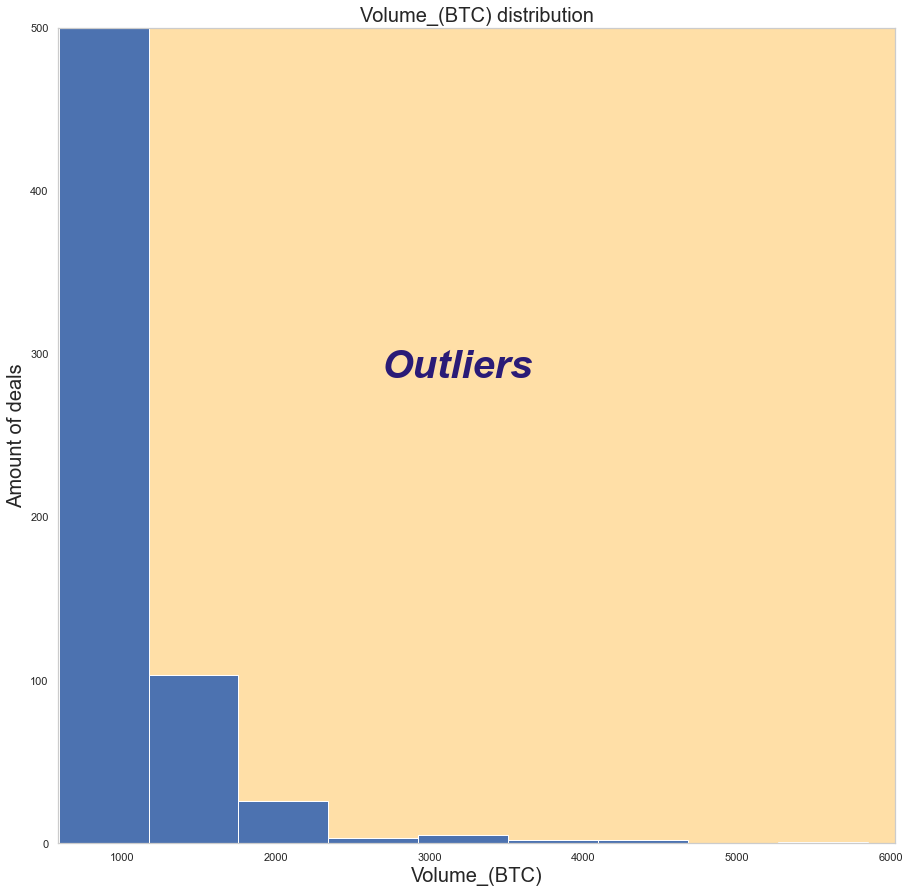

In [15]:
mean_volume_btc2 = df['Volume_(BTC)'].mean()
sd_volume_btc2 = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc2 = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc2 = Q3_volume_btc2 + 1.5 * (Q3_volume_btc2 - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc2 = df['Volume_(BTC)'].min() + 600
left_border_volume_btc2 = min_volume_btc2 * 0.97
max_volume_btc2 = df['Volume_(BTC)'].max()
right_border_volume_btc2 = max_volume_btc2 * 1.03
ceil_volume_btc2 = 500

plt.axis([left_border_volume_btc2, right_border_volume_btc2, 0, ceil_volume_btc2])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc2 - half_thicc, b_u_volume_btc2 - half_thicc], [0, ceil_volume_btc2], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc2, 0), right_border_volume_btc2 - b_u_volume_btc2, ceil_volume_btc2, color="#FFDFA7"))
plt.gca().text((right_border_volume_btc2 + b_u_volume_btc2) / 2.25, ceil_volume_btc2 / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Volume_(BTC)']);

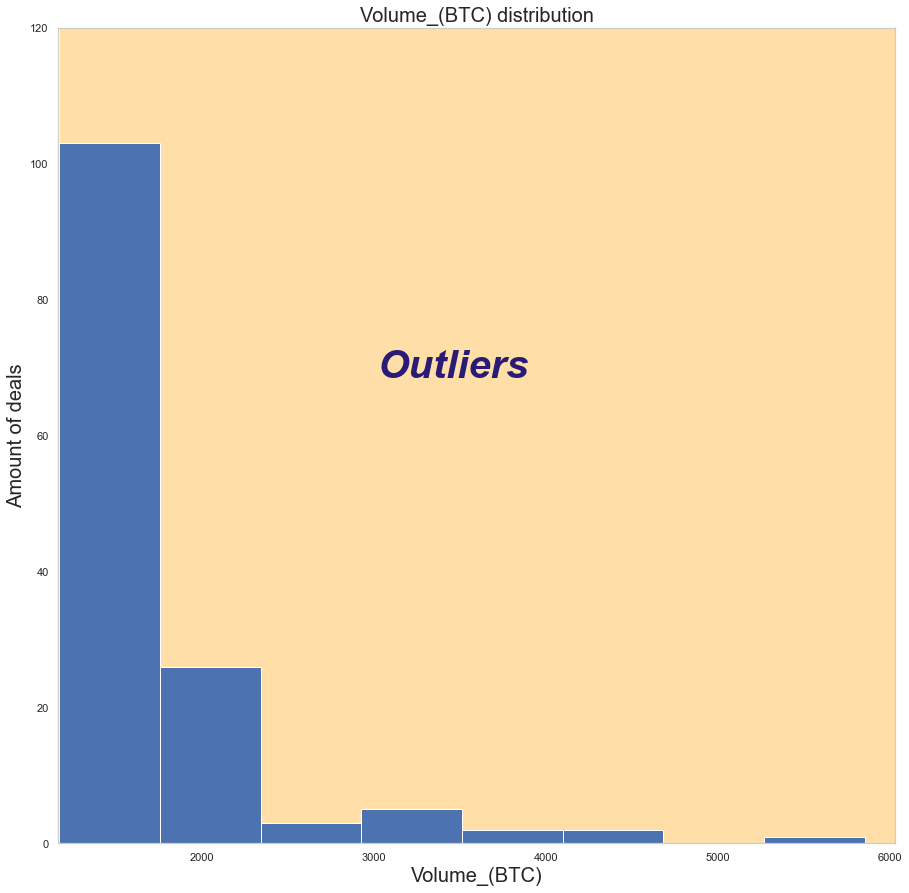

In [16]:
mean_volume_btc3 = df['Volume_(BTC)'].mean()
sd_volume_btc3 = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc3 = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc3 = Q3_volume_btc3 + 1.5 * (Q3_volume_btc3 - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc3 = df['Volume_(BTC)'].min() + 1200
left_border_volume_btc3 = min_volume_btc3 * 0.97
max_volume_btc3 = df['Volume_(BTC)'].max()
right_border_volume_btc3 = max_volume_btc3 * 1.03
ceil_volume_btc3 = 120

plt.axis([left_border_volume_btc3, right_border_volume_btc3, 0, ceil_volume_btc3])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc3 - half_thicc, b_u_volume_btc3 - half_thicc], [0, ceil_volume_btc3], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc3, 0), right_border_volume_btc3 - b_u_volume_btc3, ceil_volume_btc3, color="#FFDFA7"))
plt.gca().text((right_border_volume_btc3 + b_u_volume_btc3) / 2, ceil_volume_btc3 / 1.75, 'Outliers',
               fontdict={'color':  '#2A1B77', 'weight': 'bold', 'size': 40, 'style': 'italic'})
plt.grid(True)
plt.hist(df['Volume_(BTC)']);

## 4. <a href="#toc" title="К содержанию" id="attributes-correlation" style="text-decoration: none; color:#81BCD9">Анализ корреляции атрибутов</a>
***

- какие атрибуты высококоррелированы, определить характер корреляции 
- какие атрибуты не имеют корреляцию
- постройте графики рассеивания (предпочтительнее матрицу графиков рассеивания)
- проанализируйте полученные результаты.